In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error

In [158]:
#from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder

# from sklearn.linear_model import LinearRegression      
# from sklearn.ensemble import RandomForestRegressor     
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import mean_absolute_error

In [292]:
holiday_data = pd.read_csv("../data/holidays_events.csv")
oil_data = pd.read_csv("../data/oil.csv")
stores_data = pd.read_csv("../data/stores.csv")
transactions_data = pd.read_csv("../data/transactions.csv")
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")


In [160]:
holiday_data.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [161]:
holiday_data["type"].unique()

<ArrowStringArray>
['Holiday', 'Transfer', 'Additional', 'Bridge', 'Work Day', 'Event']
Length: 6, dtype: str

In [162]:
holiday_data["locale"].unique()

<ArrowStringArray>
['Local', 'Regional', 'National']
Length: 3, dtype: str

In [163]:
holiday_data["transferred"].unique()

array([False,  True])

In [164]:
holiday_data.describe()

,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,312,6,3,24,103,2
top,2014-06-25,Holiday,National,Ecuador,Carnaval,False
freq,4,221,174,174,10,338


In [165]:
holiday_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   type         350 non-null    str  
 2   locale       350 non-null    str  
 3   locale_name  350 non-null    str  
 4   description  350 non-null    str  
 5   transferred  350 non-null    bool 
dtypes: bool(1), str(5)
memory usage: 32.1 KB


In [166]:
oil_data.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [167]:
oil_data.describe()


,dcoilwtico
count,1175.000000
mean,67.714366
std,25.630476
min,26.190000
25%,46.405000
50%,53.190000
75%,95.660000
max,110.620000


In [168]:
oil_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 31.1 KB


In [169]:
stores_data.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [170]:
stores_data.describe()

,store_nbr,cluster
count,54.000000,54.000000
mean,27.500000,8.481481
std,15.732133,4.693395
min,1.000000,1.000000
25%,14.250000,4.000000
50%,27.500000,8.500000
75%,40.750000,13.000000
max,54.000000,17.000000


In [171]:
transactions_data.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [172]:
train_data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [173]:
train_data.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [174]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB


# EDA

In [175]:
train_data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [176]:
dates = pd.to_datetime(train_data['date'])
print(dates)
print("")
unique = dates.nunique()
print(unique)
date_ran = pd.date_range(start=dates.min(), end=dates.max())
print("")
print(len(date_ran))

0         2013-01-01
1         2013-01-01
2         2013-01-01
3         2013-01-01
4         2013-01-01
             ...    
3000883   2017-08-15
3000884   2017-08-15
3000885   2017-08-15
3000886   2017-08-15
3000887   2017-08-15
Name: date, Length: 3000888, dtype: datetime64[us]

1684

1688


In [177]:
# missing 4 days

In [178]:
set1 = set(dates)
set2 = set(date_ran)
set3 = set2.difference(set1)
set3


{Timestamp('2013-12-25 00:00:00'),
 Timestamp('2014-12-25 00:00:00'),
 Timestamp('2015-12-25 00:00:00'),
 Timestamp('2016-12-25 00:00:00')}

In [179]:
# - missing Christmas in 4 years

<Axes: xlabel='date'>

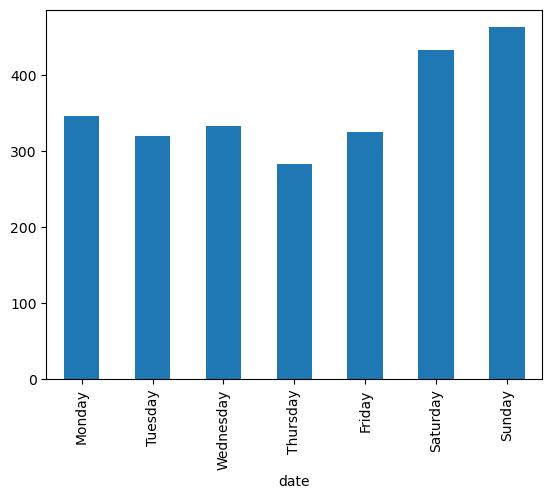

In [180]:
# weekly 
train_data_weekly = pd.to_datetime(train_data["date"])
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly_sales = train_data.groupby(train_data_weekly.dt.day_name())['sales'].mean().reindex(days_order)

weekly_sales.plot(kind = 'bar')

<Axes: ylabel='family'>

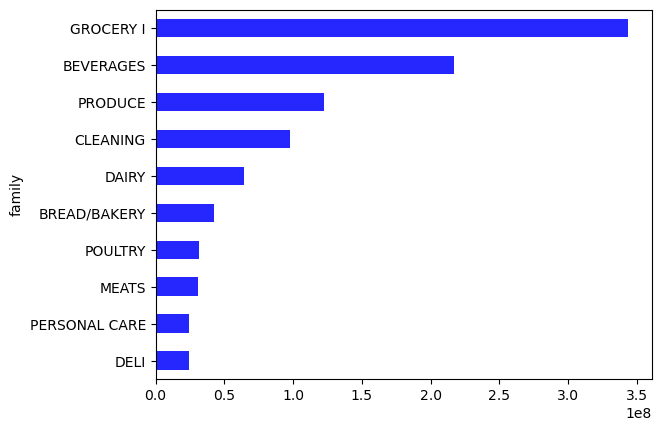

In [181]:
top10_families = train_data.groupby(train_data['family'])['sales'].sum().sort_values().tail(10)
top10_families.plot(kind='barh', color='blue', alpha=0.85)

In [182]:
#average daily sales
mean_daily_sales = train_data.groupby('date')['sales'].sum().mean()
print(mean_daily_sales)

637556.3849186868


In [183]:
mean_daily_per_store = train_data.groupby(['date', 'store_nbr'])['sales'].sum().mean()
print(mean_daily_per_store)

11806.59972071642


###  Zero sales

In [184]:
zero_sales = train_data[train_data['sales'] == 0]
zero_sales

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
...,...,...,...,...,...,...
3000839,3000839,2017-08-15,8,HOME APPLIANCES,0.0,0
3000853,3000853,2017-08-15,8,SCHOOL AND OFFICE SUPPLIES,0.0,0
3000856,3000856,2017-08-15,9,BABY CARE,0.0,0
3000859,3000859,2017-08-15,9,BOOKS,0.0,0


In [185]:
x = zero_sales.groupby('family')['sales'].count()
y = train_data.groupby('family')['sales'].count()

In [186]:
z = x / y
z.sort_values(ascending= False)
z.sort_values(ascending= False).head(10)

family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865
Name: sales, dtype: float64

In [187]:
cat_to_filter = z[z > 0.3].index
cat_to_filter

Index(['BABY CARE', 'BOOKS', 'CELEBRATION', 'HARDWARE', 'HOME AND KITCHEN I',
       'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR',
       'LAWN AND GARDEN', 'MAGAZINES', 'PET SUPPLIES',
       'PLAYERS AND ELECTRONICS', 'SCHOOL AND OFFICE SUPPLIES'],
      dtype='str', name='family')

In [188]:
train_data[train_data['sales'] > 0].groupby('family')['date'].min().loc[cat_to_filter]

family
BABY CARE                     2014-03-01
BOOKS                         2016-10-08
CELEBRATION                   2014-01-01
HARDWARE                      2013-01-02
HOME AND KITCHEN I            2014-01-01
HOME AND KITCHEN II           2014-01-01
HOME APPLIANCES               2013-01-02
HOME CARE                     2014-01-01
LADIESWEAR                    2014-01-02
LAWN AND GARDEN               2013-01-01
MAGAZINES                     2014-01-01
PET SUPPLIES                  2014-01-01
PLAYERS AND ELECTRONICS       2014-01-01
SCHOOL AND OFFICE SUPPLIES    2014-01-02
Name: date, dtype: str

In [189]:
daily_sales = train_data.groupby('date')['sales'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

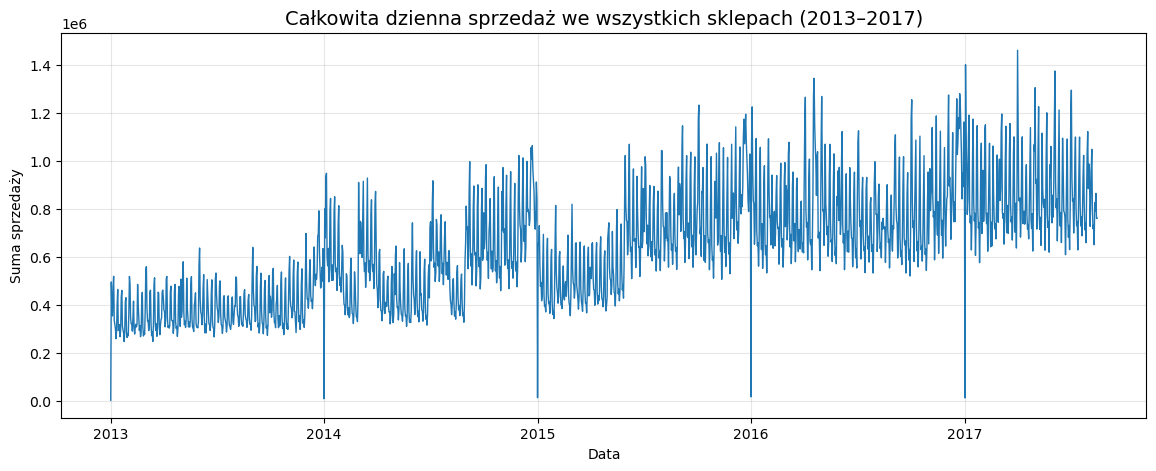

In [190]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='#1f77b4', linewidth=1)
plt.title('Całkowita dzienna sprzedaż we wszystkich sklepach (2013–2017)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Suma sprzedaży')
plt.grid(True, alpha=0.3)
plt.show()

In [191]:
train_data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### OIL

In [192]:
oil_data.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [193]:
dates_oil = pd.to_datetime(oil_data['date'])
print(dates_oil)
print("")
unique_oil = dates_oil.nunique()
print(unique_oil)
date_ran_oil = pd.date_range(start=dates_oil.min(), end=dates_oil.max())
print("")
print(len(date_ran_oil))

0      2013-01-01
1      2013-01-02
2      2013-01-03
3      2013-01-04
4      2013-01-07
          ...    
1213   2017-08-25
1214   2017-08-28
1215   2017-08-29
1216   2017-08-30
1217   2017-08-31
Name: date, Length: 1218, dtype: datetime64[us]

1218

1704


In [194]:
set4 = set(dates_oil)
set5 = set(date_ran_oil)
set6 = set5.difference(set4)
set6


{Timestamp('2013-01-05 00:00:00'),
 Timestamp('2013-01-06 00:00:00'),
 Timestamp('2013-01-12 00:00:00'),
 Timestamp('2013-01-13 00:00:00'),
 Timestamp('2013-01-19 00:00:00'),
 Timestamp('2013-01-20 00:00:00'),
 Timestamp('2013-01-26 00:00:00'),
 Timestamp('2013-01-27 00:00:00'),
 Timestamp('2013-02-02 00:00:00'),
 Timestamp('2013-02-03 00:00:00'),
 Timestamp('2013-02-09 00:00:00'),
 Timestamp('2013-02-10 00:00:00'),
 Timestamp('2013-02-16 00:00:00'),
 Timestamp('2013-02-17 00:00:00'),
 Timestamp('2013-02-23 00:00:00'),
 Timestamp('2013-02-24 00:00:00'),
 Timestamp('2013-03-02 00:00:00'),
 Timestamp('2013-03-03 00:00:00'),
 Timestamp('2013-03-09 00:00:00'),
 Timestamp('2013-03-10 00:00:00'),
 Timestamp('2013-03-16 00:00:00'),
 Timestamp('2013-03-17 00:00:00'),
 Timestamp('2013-03-23 00:00:00'),
 Timestamp('2013-03-24 00:00:00'),
 Timestamp('2013-03-30 00:00:00'),
 Timestamp('2013-03-31 00:00:00'),
 Timestamp('2013-04-06 00:00:00'),
 Timestamp('2013-04-07 00:00:00'),
 Timestamp('2013-04-

In [195]:
# see if in missing days there are different days than SAT and SUN
missing_ser = pd.DataFrame({'date' : list(set6)})
missing_weekdays = missing_ser[missing_ser['date'].dt.dayofweek < 5].sort_values('date').reset_index(drop=True)
missing_weekdays['day_name'] = missing_weekdays['date'].dt.day_name()
missing_weekdays


,date,day_name


In [196]:
oil_nans = oil_data[oil_data['dcoilwtico'].isna()].copy()
oil_nans['date'] = pd.to_datetime(oil_nans['date'])
oil_nans['day_name'] = oil_nans['date'].dt.day_name()

oil_nans[['date', 'day_name', 'dcoilwtico']].head(10)

,date,day_name,dcoilwtico
0,2013-01-01,Tuesday,NaN
14,2013-01-21,Monday,NaN
34,2013-02-18,Monday,NaN
63,2013-03-29,Friday,NaN
104,2013-05-27,Monday,NaN
132,2013-07-04,Thursday,NaN
174,2013-09-02,Monday,NaN
237,2013-11-28,Thursday,NaN
256,2013-12-25,Wednesday,NaN
261,2014-01-01,Wednesday,NaN


In [197]:
oil_data['date'] = pd.to_datetime(oil_data['date'])


In [198]:
full_dates = pd.DataFrame({'date': pd.date_range(oil_data['date'].min(), oil_data['date'].max())})

In [199]:
oil_clean = pd.merge(full_dates, oil_data, on = 'date', how = 'left')
oil_clean['dcoilwtico'] = oil_clean['dcoilwtico'].ffill().bfill()
oil_clean

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,93.12
...,...,...
1699,2017-08-27,47.65
1700,2017-08-28,46.40
1701,2017-08-29,46.46
1702,2017-08-30,45.96


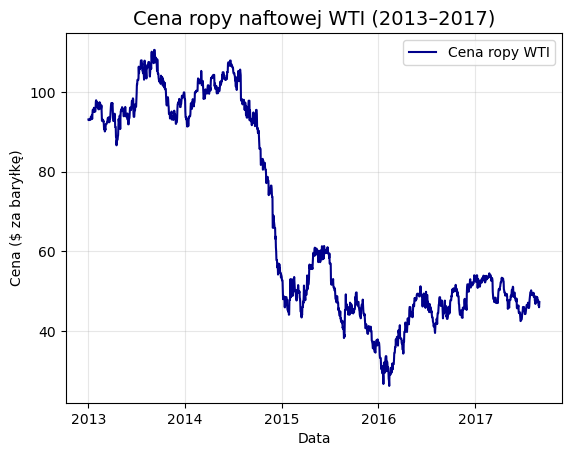

In [200]:
plt.plot(oil_clean["date"], oil_clean['dcoilwtico'], color='darkblue', linewidth=1.5, label='Cena ropy WTI')
plt.title('Cena ropy naftowej WTI (2013–2017)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Cena ($ za baryłkę)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Holiday Events

In [201]:
holiday_data.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [202]:
transfered_holidays = holiday_data[holiday_data['transferred'] == True]
transfered_holidays['day_name'] = pd.to_datetime(transfered_holidays['date'])
transfered_holidays['day_name'] =transfered_holidays['day_name'].dt.day_name()
transfered_holidays

,date,type,locale,locale_name,description,transferred,day_name
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True,Tuesday
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True,Wednesday
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True,Thursday
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True,Tuesday
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True,Monday
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True,Wednesday
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True,Sunday
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True,Wednesday
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True,Wednesday
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True,Thursday


In [203]:
transfered_holidays = holiday_data[holiday_data['type'] == 'Transfer']
transfered_holidays['day_name'] = pd.to_datetime(transfered_holidays['date'])
transfered_holidays['day_name'] = transfered_holidays['day_name'].dt.day_name()
transfered_holidays

,date,type,locale,locale_name,description,transferred,day_name
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False,Friday
73,2013-10-11,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False,Friday
136,2014-10-10,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False,Friday
256,2016-05-27,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False,Friday
265,2016-07-24,Transfer,Local,Guayaquil,Traslado Fundacion de Guayaquil,False,Sunday
269,2016-08-12,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,Friday
298,2017-01-02,Transfer,National,Ecuador,Traslado Primer dia del ano,False,Monday
304,2017-04-13,Transfer,Local,Cuenca,Fundacion de Cuenca,False,Thursday
313,2017-05-26,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False,Friday
325,2017-08-11,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False,Friday


In [204]:
bridged_holidays = holiday_data[holiday_data['type'] == 'Bridge']
bridged_holidays['day_name'] = pd.to_datetime(bridged_holidays['date'])
bridged_holidays['day_name'] = bridged_holidays['day_name'].dt.day_name()
bridged_holidays

,date,type,locale,locale_name,description,transferred,day_name
35,2012-12-24,Bridge,National,Ecuador,Puente Navidad,False,Monday
39,2012-12-31,Bridge,National,Ecuador,Puente Primer dia del ano,False,Monday
156,2014-12-26,Bridge,National,Ecuador,Puente Navidad,False,Friday
160,2015-01-02,Bridge,National,Ecuador,Puente Primer dia del ano,False,Friday
277,2016-11-04,Bridge,National,Ecuador,Puente Dia de Difuntos,False,Friday


In [205]:
work_day = holiday_data[holiday_data['type'] == 'Work Day']
work_day['day_name'] = pd.to_datetime(work_day['date'])
work_day['day_name'] = work_day['day_name'].dt.day_name()
work_day

,date,type,locale,locale_name,description,transferred,day_name
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False,Saturday
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano,False,Saturday
149,2014-12-20,Work Day,National,Ecuador,Recupero Puente Navidad,False,Saturday
161,2015-01-10,Work Day,National,Ecuador,Recupero Puente Primer dia del ano,False,Saturday
283,2016-11-12,Work Day,National,Ecuador,Recupero Puente Dia de Difuntos,False,Saturday


### Geografic impact

In [206]:
holiday_data['locale'].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [207]:
geo_loc = holiday_data[holiday_data['locale'] == 'Local'].reset_index()
geo_loc.tail(10)


,index,date,type,locale,locale_name,description,transferred
142,329,2017-09-29,Transfer,Local,Ibarra,Fundacion de Ibarra,False
143,330,2017-10-07,Holiday,Local,Quevedo,Cantonizacion de Quevedo,False
144,336,2017-11-10,Holiday,Local,Guaranda,Independencia de Guaranda,False
145,337,2017-11-11,Holiday,Local,Latacunga,Independencia de Latacunga,False
146,338,2017-11-12,Holiday,Local,Ambato,Independencia de Ambato,False
147,339,2017-12-05,Additional,Local,Quito,Fundacion de Quito-1,False
148,340,2017-12-06,Holiday,Local,Quito,Fundacion de Quito,True
149,341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
150,342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False
151,344,2017-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False


In [208]:
geo_reg = holiday_data[holiday_data['locale'] == 'Regional'].reset_index()
geo_reg.head()

,index,date,type,locale,locale_name,description,transferred
0,1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
1,7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
2,23,2012-11-06,Holiday,Regional,Santo Domingo de los Tsachilas,Provincializacion de Santo Domingo,False
3,24,2012-11-07,Holiday,Regional,Santa Elena,Provincializacion Santa Elena,False
4,47,2013-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False


In [209]:
stores_data.head(10)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [210]:
# if there is more than one holiday at the time
print(holiday_data['date'].count())
holiday_data['date'].nunique()

350


312

In [211]:
duplicated = holiday_data[holiday_data['date'].duplicated(keep = False) == True].index
duplicated 


Index([  7,   8,   9,  10,  11,  32,  33,  35,  36,  39,  40,  54,  55,  58,
        59,  60,  61,  62,  85,  86, 110, 111, 112, 113, 118, 119, 151, 152,
       156, 157, 176, 177, 178, 179, 180, 204, 205, 224, 225, 235, 236, 242,
       243, 244, 245, 249, 250, 258, 259, 260, 261, 262, 264, 265, 282, 283,
       290, 291, 305, 306, 315, 316, 317, 318, 319, 341, 342, 344, 345],
      dtype='int64')

### looking for earthquake

In [212]:
EQ_data = holiday_data[holiday_data['description'].str.contains("Terremoto")]
EQ_data['date'] = pd.to_datetime(EQ_data['date'])
EQ_data


,date,type,locale,locale_name,description,transferred
219,2016-04-16,Event,National,Ecuador,Terremoto Manabi,False
220,2016-04-17,Event,National,Ecuador,Terremoto Manabi+1,False
221,2016-04-18,Event,National,Ecuador,Terremoto Manabi+2,False
222,2016-04-19,Event,National,Ecuador,Terremoto Manabi+3,False
223,2016-04-20,Event,National,Ecuador,Terremoto Manabi+4,False
225,2016-04-21,Event,National,Ecuador,Terremoto Manabi+5,False
226,2016-04-22,Event,National,Ecuador,Terremoto Manabi+6,False
227,2016-04-23,Event,National,Ecuador,Terremoto Manabi+7,False
228,2016-04-24,Event,National,Ecuador,Terremoto Manabi+8,False
229,2016-04-25,Event,National,Ecuador,Terremoto Manabi+9,False


In [213]:
EQ_range = pd.date_range(start=EQ_data['date'].min(), end=EQ_data['date'].max())
EQ_range

DatetimeIndex(['2016-04-16', '2016-04-17', '2016-04-18', '2016-04-19',
               '2016-04-20', '2016-04-21', '2016-04-22', '2016-04-23',
               '2016-04-24', '2016-04-25', '2016-04-26', '2016-04-27',
               '2016-04-28', '2016-04-29', '2016-04-30', '2016-05-01',
               '2016-05-02', '2016-05-03', '2016-05-04', '2016-05-05',
               '2016-05-06', '2016-05-07', '2016-05-08', '2016-05-09',
               '2016-05-10', '2016-05-11', '2016-05-12', '2016-05-13',
               '2016-05-14', '2016-05-15', '2016-05-16'],
              dtype='datetime64[us]', freq='D')

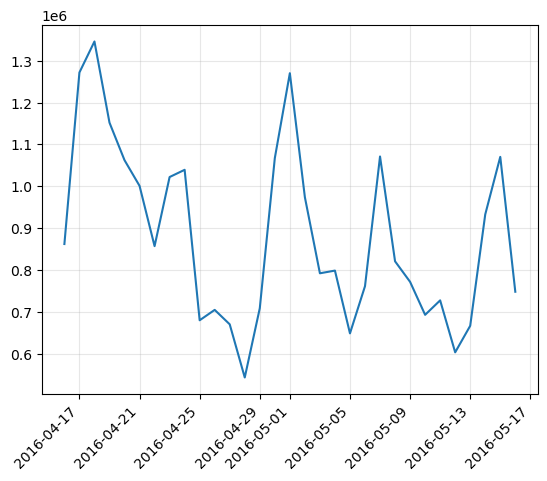

In [214]:
EQ_sales = daily_sales[daily_sales['date'].isin(EQ_range)]
plt.plot(EQ_sales['date'], EQ_sales['sales'])
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.show()

### Stores

In [215]:
stores_data.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [216]:
# how many stores
stores_data.shape

(54, 5)

In [217]:
stores_data['cluster'].nunique()

17

In [218]:
stores_data['cluster'].value_counts()

cluster
3     7
6     6
10    6
15    5
13    4
14    4
8     3
4     3
1     3
11    3
9     2
7     2
2     2
12    1
16    1
5     1
17    1
Name: count, dtype: int64

In [219]:
stores_data['type'].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

In [220]:
stores_data['city'].nunique()

22

In [221]:
stores_data['state'].nunique()

16

In [222]:
stores_data['city'].value_counts()

city
Quito            18
Guayaquil         8
Santo Domingo     3
Cuenca            3
Latacunga         2
Ambato            2
Machala           2
Manta             2
Cayambe           1
Riobamba          1
Ibarra            1
Guaranda          1
Puyo              1
Salinas           1
Daule             1
Babahoyo          1
Quevedo           1
Playas            1
Libertad          1
Loja              1
Esmeraldas        1
El Carmen         1
Name: count, dtype: int64

### Transactions

In [223]:
transactions_data.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [224]:
transactions_data.describe()

,store_nbr,transactions
count,83488.000000,83488.000000
mean,26.939237,1694.602158
std,15.608204,963.286644
min,1.000000,5.000000
25%,13.000000,1046.000000
50%,27.000000,1393.000000
75%,40.000000,2079.000000
max,54.000000,8359.000000


In [225]:
transactions_data.notnull().count()

date            83488
store_nbr       83488
transactions    83488
dtype: int64

# Feature Eng

## Datetime Features

In [226]:
train_data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [227]:
type(train_data['date'])

pandas.Series

In [228]:
train_data['date'] = pd.to_datetime(train_data['date'])
train_data['day'] = train_data['date'].dt.day_name()
train_data['month'] = train_data['date'].dt.month_name()
train_data['year'] = train_data['date'].dt.year
train_data['DayofWeek'] = train_data['date'].dt.day_of_week

train_data

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Tuesday,January,2013,1
1,1,2013-01-01,1,BABY CARE,0.000,0,Tuesday,January,2013,1
2,2,2013-01-01,1,BEAUTY,0.000,0,Tuesday,January,2013,1
3,3,2013-01-01,1,BEVERAGES,0.000,0,Tuesday,January,2013,1
4,4,2013-01-01,1,BOOKS,0.000,0,Tuesday,January,2013,1
...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Tuesday,August,2017,1
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Tuesday,August,2017,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Tuesday,August,2017,1
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Tuesday,August,2017,1


In [229]:
train_data['is_weekend'] = np.where((train_data['DayofWeek'] == 5) | (train_data['DayofWeek'] == 6), 1, 0)

In [230]:
train_data['day_of_month'] = train_data['date'].dt.day
train_data['is_payday'] = np.where((train_data['date'].dt.day == 15) | (train_data['date'].dt.day == train_data['date'].dt.is_month_end), 1, 0)
train_data

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Tuesday,January,2013,1,0,1,0
1,1,2013-01-01,1,BABY CARE,0.000,0,Tuesday,January,2013,1,0,1,0
2,2,2013-01-01,1,BEAUTY,0.000,0,Tuesday,January,2013,1,0,1,0
3,3,2013-01-01,1,BEVERAGES,0.000,0,Tuesday,January,2013,1,0,1,0
4,4,2013-01-01,1,BOOKS,0.000,0,Tuesday,January,2013,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Tuesday,August,2017,1,0,15,1
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Tuesday,August,2017,1,0,15,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Tuesday,August,2017,1,0,15,1
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Tuesday,August,2017,1,0,15,1


In [231]:
train_data['is_month_start']= train_data['date'].dt.is_month_start
train_data['is_month_end'] = train_data['date'].dt.is_month_end
train_data

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Tuesday,January,2013,1,0,1,0,True,False
1,1,2013-01-01,1,BABY CARE,0.000,0,Tuesday,January,2013,1,0,1,0,True,False
2,2,2013-01-01,1,BEAUTY,0.000,0,Tuesday,January,2013,1,0,1,0,True,False
3,3,2013-01-01,1,BEVERAGES,0.000,0,Tuesday,January,2013,1,0,1,0,True,False
4,4,2013-01-01,1,BOOKS,0.000,0,Tuesday,January,2013,1,0,1,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Tuesday,August,2017,1,0,15,1,False,False
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Tuesday,August,2017,1,0,15,1,False,False
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Tuesday,August,2017,1,0,15,1,False,False
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Tuesday,August,2017,1,0,15,1,False,False


# Holiday Features

In [232]:
holiday_data.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [233]:
holiday_data['date'] = pd.to_datetime(holiday_data['date'])

In [234]:
holidays_clean = holiday_data[(holiday_data['transferred'] == False) & (holiday_data['type'] != 'Work Day')].copy()
holidays_clean.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         333 non-null    datetime64[us]
 1   type         333 non-null    str           
 2   locale       333 non-null    str           
 3   locale_name  333 non-null    str           
 4   description  333 non-null    str           
 5   transferred  333 non-null    bool          
dtypes: bool(1), datetime64[us](1), str(4)
memory usage: 29.9 KB


In [235]:
national_holidays = holidays_clean[holidays_clean['locale'] == 'National'][['date']].drop_duplicates()
national_holidays['is_national_holiday'] = 1

events = holidays_clean[holidays_clean['type'] == 'Event'][['date']].drop_duplicates()
events['is_event'] = 1

In [236]:
train_data = train_data.merge(national_holidays, on='date', how='left')
train_data = train_data.merge(events, on='date', how='left')

In [237]:
train_data.head(3)

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end,is_national_holiday,is_event
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1.0,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1.0,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1.0,NaN


In [238]:
train_data['is_national_holiday'] = train_data['is_national_holiday'].fillna(0).astype(int)
train_data['is_event'] = train_data['is_event'].fillna(0).astype(int)
train_data.head(3)

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end,is_national_holiday,is_event
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0


In [239]:
print("Liczba wierszy:", len(train_data))
assert len(train_data) == 3000888, "Uwaga! Liczba wierszy się zmieniła — gdzieś wciąż był dubel daty!"

Liczba wierszy: 3000888


In [240]:
print(train_data[['is_national_holiday', 'is_event']].isna().sum())

is_national_holiday    0
is_event               0
dtype: int64


In [241]:
print(train_data['is_national_holiday'].value_counts())
print("---")
print(train_data['is_event'].value_counts())

is_national_holiday
0    2767446
1     233442
Name: count, dtype: int64
---
is_event
0    2902878
1      98010
Name: count, dtype: int64


In [242]:
train_data[train_data['date'] == '2013-01-01'][['date', 'store_nbr', 'is_national_holiday', 'is_event']].head()

,date,store_nbr,is_national_holiday,is_event
0,2013-01-01,1,1,0
1,2013-01-01,1,1,0
2,2013-01-01,1,1,0
3,2013-01-01,1,1,0
4,2013-01-01,1,1,0


In [243]:
oil_clean.head()

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,93.12


In [244]:
train_data = train_data.merge(oil_clean[['date', 'dcoilwtico']], on='date', how='left')

In [245]:
train_data.head()

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end,is_national_holiday,is_event,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14


In [246]:
oil_clean = oil_clean.sort_values('date').reset_index(drop=True)

In [247]:
#rolling mean
oil_clean['oil_rolling_mean_7'] = oil_clean['dcoilwtico'].rolling(window = 7, min_periods = 1).mean()

In [248]:
oil_clean.head(10)

,date,dcoilwtico,oil_rolling_mean_7
0,2013-01-01,93.14,93.140000
1,2013-01-02,93.14,93.140000
2,2013-01-03,92.97,93.083333
3,2013-01-04,93.12,93.092500
4,2013-01-05,93.12,93.098000
5,2013-01-06,93.12,93.101667
6,2013-01-07,93.20,93.115714
7,2013-01-08,93.21,93.125714
8,2013-01-09,93.08,93.117143
9,2013-01-10,93.81,93.237143


In [249]:
oil_clean['oil_lag_7'] = oil_clean['dcoilwtico'].shift(7)

In [250]:
oil_clean.head(10)

,date,dcoilwtico,oil_rolling_mean_7,oil_lag_7
0,2013-01-01,93.14,93.140000,NaN
1,2013-01-02,93.14,93.140000,NaN
2,2013-01-03,92.97,93.083333,NaN
3,2013-01-04,93.12,93.092500,NaN
4,2013-01-05,93.12,93.098000,NaN
5,2013-01-06,93.12,93.101667,NaN
6,2013-01-07,93.20,93.115714,NaN
7,2013-01-08,93.21,93.125714,93.14
8,2013-01-09,93.08,93.117143,93.14
9,2013-01-10,93.81,93.237143,92.97


In [251]:
train_data = train_data.merge(oil_clean[['date', 'oil_rolling_mean_7', 'oil_lag_7']], on='date', how='left')

In [252]:
train_data.head(2)

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end,is_national_holiday,is_event,dcoilwtico,oil_rolling_mean_7,oil_lag_7
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14,93.14,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14,93.14,NaN


In [253]:
train_data['oil_lag_7'] = train_data['oil_lag_7'].fillna(train_data['dcoilwtico'])
train_data.head(2)

,id,date,store_nbr,family,sales,onpromotion,day,month,year,DayofWeek,is_weekend,day_of_month,is_payday,is_month_start,is_month_end,is_national_holiday,is_event,dcoilwtico,oil_rolling_mean_7,oil_lag_7
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14,93.14,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,Tuesday,January,2013,1,0,1,0,True,False,1,0,93.14,93.14,93.14


# Sales

In [254]:
train_data = train_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

In [255]:
lags = [16, 21, 28, 35]
for lag in lags:
    train_data[f'sales_lag_{lag}'] = (
        train_data.groupby(['store_nbr', 'family'])['sales'].shift(lag)
    )

In [256]:
for window in [7, 14, 30]:
    train_data[f'sales_rolling_mean_{window}'] = (
        train_data.groupby(['store_nbr', 'family'])['sales_lag_16']
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

In [257]:
# Sprawdzamy pierwsze 20 wierszy dla wybranego sklepu i rodziny
train_data[['date', 'store_nbr', 'family', 'sales', 'sales_lag_16', 'sales_rolling_mean_7']].head(20)

,date,store_nbr,family,sales,sales_lag_16,sales_rolling_mean_7
0,2013-01-01,1,AUTOMOTIVE,0.0,NaN,NaN
1,2013-01-02,1,AUTOMOTIVE,2.0,NaN,NaN
2,2013-01-03,1,AUTOMOTIVE,3.0,NaN,NaN
3,2013-01-04,1,AUTOMOTIVE,3.0,NaN,NaN
4,2013-01-05,1,AUTOMOTIVE,5.0,NaN,NaN
5,2013-01-06,1,AUTOMOTIVE,2.0,NaN,NaN
6,2013-01-07,1,AUTOMOTIVE,0.0,NaN,NaN
7,2013-01-08,1,AUTOMOTIVE,2.0,NaN,NaN
8,2013-01-09,1,AUTOMOTIVE,2.0,NaN,NaN
9,2013-01-10,1,AUTOMOTIVE,2.0,NaN,NaN


In [258]:
train_data_clean = train_data.dropna(subset=['sales_lag_35']).copy()

print("Wiersze przed usunięciem NaN:", len(train_data))
print("Wiersze po usunięciu NaN:", len(train_data_clean))

Wiersze przed usunięciem NaN: 3000888
Wiersze po usunięciu NaN: 2938518


In [259]:
train_data_clean['family'] = train_data_clean['family'].astype('category').cat.codes

In [260]:
val_start_date = '2017-08-01'
X_train = train_data_clean[train_data_clean['date'] < val_start_date]
y_train = X_train['sales']

In [261]:
X_val  = train_data_clean[train_data_clean['date'] >= val_start_date]
y_val = X_val['sales']

In [262]:
features = [c for c in X_train.columns if c not in ['date', 'sales', 'id']]
X_train_features = X_train[features]
X_val_features = X_val[features]

# ML - Baseline

In [263]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [264]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

In [265]:
for col in ['day', 'month']:
    if col in X_train_features.columns:
        X_train_features[col] = X_train_features[col].astype('category').cat.codes
        X_val_features[col] = X_val_features[col].astype('category').cat.codes

In [266]:
model.fit(
    X_train_features, y_train_log,
    eval_set=[(X_val_features, y_val_log)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080003 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2915
[LightGBM] [Info] Number of data points in the train set: 2911788, number of used features: 24
[LightGBM] [Info] Start training from score 2.939080


LGBMRegressor(learning_rate=0.05, n_estimators=1000, n_jobs=-1, random_state=42)

In [267]:
preds_log = model.predict(X_val_features)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)  # Wykluczamy ujemne wartości sprzedaży

In [268]:
val_rmsle = root_mean_squared_error(y_val_log, preds_log)
print(f"Baseline RMSLE: {val_rmsle:.4f}")

Baseline RMSLE: 0.4091


In [269]:
feature_imp = pd.DataFrame({
    'Value': model.feature_importances_,
    'Feature': X_train_features.columns
}).sort_values(by="Value", ascending=False)

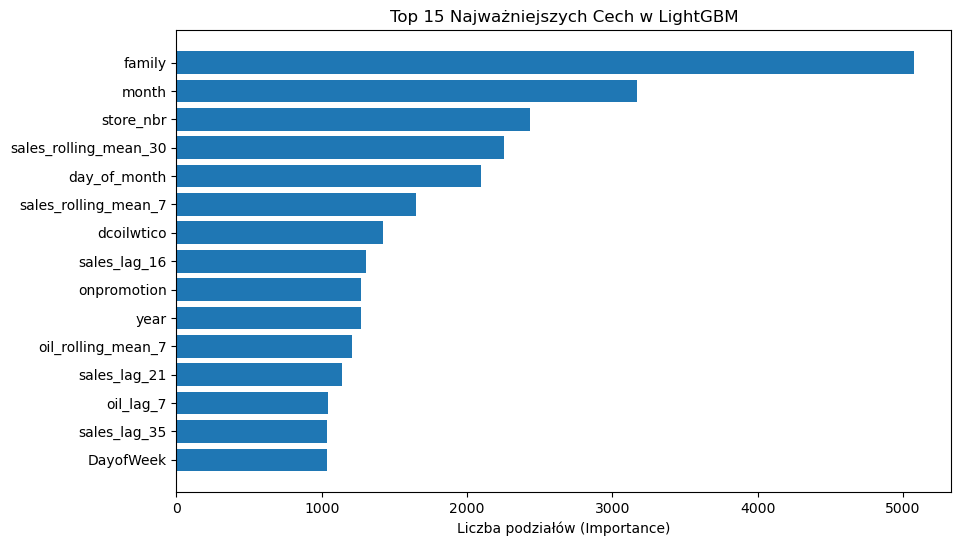

In [270]:
plt.figure(figsize=(10, 6))
plt.barh(feature_imp['Feature'][:15][::-1], feature_imp['Value'][:15][::-1])
plt.title('Top 15 Najważniejszych Cech w LightGBM')
plt.xlabel('Liczba podziałów (Importance)')
plt.show()

In [271]:
# for lag in [16, 21, 28]:
#     train_data[f'promo_lag_{lag}'] = train_data.groupby(['store_nbr', 'family'])['onpromotion'].shift(lag)
    


# for window in [7, 14, 30]:
#     train_data[f'promo_rolling_mean_{window}'] = (
#         train_data.groupby(['store_nbr', 'family'])['onpromotion']
#         .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
#     )

In [272]:
# train_data_clean = train_data.dropna(subset=['sales_lag_35']).copy()

In [273]:
# features = [c for c in train_data_clean.columns if c not in ['date', 'sales', 'id']]

In [274]:
# val_start_date = '2017-08-01'

# X_train = train_data_clean[train_data_clean['date'] < val_start_date][features]
# y_train = train_data_clean[train_data_clean['date'] < val_start_date]['sales']

# X_val = train_data_clean[train_data_clean['date'] >= val_start_date][features]
# y_val = train_data_clean[train_data_clean['date'] >= val_start_date]['sales']

In [275]:
# for col in ['family', 'day', 'month']:
#     if col in X_train.columns:
#         X_train[col] = X_train[col].astype('category').cat.codes
#         X_val[col] = X_val[col].astype('category').cat.codes

In [276]:
# y_train_log = np.log1p(y_train)
# y_val_log = np.log1p(y_val)

# model = LGBMRegressor(
#     n_estimators=1000,
#     learning_rate=0.05,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(
#     X_train, y_train_log,
#     eval_set=[(X_val, y_val_log)]
# )

In [277]:
# preds_log = model.predict(X_val)
# val_rmsle = root_mean_squared_error(y_val_log, preds_log)
# print(f"📊 Nowy RMSLE (Val): {val_rmsle:.4f}")

In [278]:
# train_data['is_payday'] = (
#     (train_data['date'].dt.day == 15) | 
#     (train_data['date'].dt.is_month_end)
# ).astype(int)

In [279]:
# train_data['is_payday_eve'] = (
#     (train_data['date'].dt.day == 14) | 
#     (train_data['date'].dt.day == train_data['date'].dt.days_in_month - 1)
# ).astype(int)

In [280]:
# train_data_clean = train_data.dropna(subset=['sales_lag_35']).copy()

In [281]:
# for col in ['family', 'day', 'month']:
#     if col in train_data_clean.columns:
#         train_data_clean[col] = train_data_clean[col].astype('category').cat.codes

In [282]:
# features = [c for c in train_data_clean.columns if c not in ['date', 'sales', 'id'] and not c.startswith('promo_')]

In [283]:
# val_start_date = '2017-08-01'

# X_train = train_data_clean[train_data_clean['date'] < val_start_date][features]
# y_train = train_data_clean[train_data_clean['date'] < val_start_date]['sales']

# X_val = train_data_clean[train_data_clean['date'] >= val_start_date][features]
# y_val = train_data_clean[train_data_clean['date'] >= val_start_date]['sales']

In [284]:
# y_train_log = np.log1p(y_train)
# y_val_log = np.log1p(y_val)

# model = LGBMRegressor(
#     n_estimators=1000,
#     learning_rate=0.05,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(
#     X_train, y_train_log,
#     eval_set=[(X_val, y_val_log)]
# )

In [285]:
# preds_log = model.predict(X_val)
# val_rmsle = root_mean_squared_error(y_val_log, preds_log)
# print(f"📊 RMSLE z dniami wypłat (Val): {val_rmsle:.4f}")

In [288]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_error

# 1. Kopia danych i wykluczenie zbędnych kolumn
df_model = train_data_clean.copy()
ignore_cols = ['date', 'sales', 'id']
features = [c for c in df_model.columns if c not in ignore_cols and not c.startswith('promo_')]

# 2. Podział na Train / Val
val_start_date = '2017-08-01'

train_mask = df_model['date'] < val_start_date
val_mask = df_model['date'] >= val_start_date

X_train = df_model.loc[train_mask, features].copy()
y_train = df_model.loc[train_mask, 'sales']

X_val = df_model.loc[val_mask, features].copy()
y_val = df_model.loc[val_mask, 'sales']

# 3. BEZWZGLĘDNA KONWERSJA WSZYSTKICH NIENUMERYCZNYCH KOLUMN
non_num_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

for col in non_num_cols:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_val[col] = X_val[col].astype('category').cat.codes

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# 4. Trening modeli
print("1/3 Trening LightGBM...")
lgb_model = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)])
lgb_preds_log = lgb_model.predict(X_val)

print("2/3 Trening XGBoost...")
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
xgb_preds_log = xgb_model.predict(X_val)

print("3/3 Trening CatBoost...")
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log))
cat_preds_log = cat_model.predict(X_val)

# 5. Ensemble (uśrednienie predykcji)
ensemble_preds_log = (
    0.40 * lgb_preds_log + 
    0.30 * xgb_preds_log + 
    0.30 * cat_preds_log
)

# 6. Wyniki RMSLE
print("\n--- PORÓWNANIE RMSLE ---")
print(f"LGBM RMSLE:     {root_mean_squared_error(y_val_log, lgb_preds_log):.4f}")
print(f"XGBoost RMSLE:  {root_mean_squared_error(y_val_log, xgb_preds_log):.4f}")
print(f"CatBoost RMSLE: {root_mean_squared_error(y_val_log, cat_preds_log):.4f}")
print(f"🔥 ENSEMBLE RMSLE: {root_mean_squared_error(y_val_log, ensemble_preds_log):.4f}")

1/3 Trening LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2915
[LightGBM] [Info] Number of data points in the train set: 2911788, number of used features: 24
[LightGBM] [Info] Start training from score 2.939080
2/3 Trening XGBoost...
3/3 Trening CatBoost...

--- PORÓWNANIE RMSLE ---
LGBM RMSLE:     0.4091
XGBoost RMSLE:  0.4072
CatBoost RMSLE: 0.4230
🔥 ENSEMBLE RMSLE: 0.4067


In [289]:
# Szybkie połączenie tylko XGBoost i LightGBM
optim_ensemble_preds_log = 0.60 * xgb_preds_log + 0.40 * lgb_preds_log

new_rmsle = root_mean_squared_error(y_val_log, optim_ensemble_preds_log)
print(f"🔥 Zoptymalizowany Ensemble (XGB + LGBM) RMSLE: {new_rmsle:.4f}")

🔥 Zoptymalizowany Ensemble (XGB + LGBM) RMSLE: 0.4039


In [304]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 1. Łączenie zbiorów
full_df = pd.concat([train_data, test_data], ignore_index=True)
full_df['date'] = pd.to_datetime(full_df['date'])

# Odcinamy dane sprzed 2016 roku
full_df = full_df[full_df['date'] >= '2016-01-01'].reset_index(drop=True)

# 2. Cechy kalendarzowe
full_df['year'] = full_df['date'].dt.year
full_df['month'] = full_df['date'].dt.month
full_df['day'] = full_df['date'].dt.day
full_df['DayofWeek'] = full_df['date'].dt.dayofweek
full_df['day_of_month'] = full_df['date'].dt.day
full_df['is_weekend'] = full_df['DayofWeek'].isin([5, 6]).astype(int)
full_df['is_payday'] = ((full_df['date'].dt.day == 15) | (full_df['date'].dt.is_month_end)).astype(int)

# 3. Ropa (ffill/bfill)
oil_clean = oil_data.copy()
oil_clean['date'] = pd.to_datetime(oil_clean['date'])
if 'dcoilwtico' not in full_df.columns:
    oil_clean = oil_clean.sort_values('date').reset_index(drop=True)
    oil_clean['dcoilwtico'] = oil_clean['dcoilwtico'].ffill().bfill()
    full_df = full_df.merge(oil_clean[['date', 'dcoilwtico']], on='date', how='left')
    full_df['dcoilwtico'] = full_df['dcoilwtico'].ffill().bfill()

# 4. TARGET ENCODING: Średnia sprzedaż z ostatnich 60 dni treningu per (store, family, DayofWeek)
recent_train = full_df[(full_df['date'] >= '2017-06-01') & (full_df['date'] < '2017-08-16')]

store_family_dow_mean = (
    recent_train.groupby(['store_nbr', 'family', 'DayofWeek'])['sales']
    .mean()
    .reset_index()
    .rename(columns={'sales': 'mean_sales_store_family_dow'})
)

store_family_mean = (
    recent_train.groupby(['store_nbr', 'family'])['sales']
    .mean()
    .reset_index()
    .rename(columns={'sales': 'mean_sales_store_family'})
)

full_df = full_df.merge(store_family_dow_mean, on=['store_nbr', 'family', 'DayofWeek'], how='left')
full_df = full_df.merge(store_family_mean, on=['store_nbr', 'family'], how='left')

# 5. LAGI I ŚREDNIE KROCZĄCE
full_df = full_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

full_df['sales_lag_21'] = full_df.groupby(['store_nbr', 'family'])['sales'].shift(21)
full_df['sales_lag_28'] = full_df.groupby(['store_nbr', 'family'])['sales'].shift(28)

for window in [7, 14, 30]:
    full_df[f'sales_rolling_mean_{window}'] = (
        full_df.groupby(['store_nbr', 'family'])['sales_lag_21']
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )

# 6. Kodowanie kategorii
cat_cols = ['store_nbr', 'family']
for col in cat_cols:
    full_df[col] = full_df[col].astype('category').cat.codes

features = [
    'store_nbr', 'family', 'onpromotion', 'DayofWeek', 'day_of_month', 'is_weekend', 
    'is_payday', 'dcoilwtico', 'sales_lag_21', 'sales_lag_28',
    'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_30',
    'mean_sales_store_family_dow', 'mean_sales_store_family'
]

# 7. Podział na Train / Val / Test
train_mask = (full_df['date'] < '2017-08-01')
val_mask = (full_df['date'] >= '2017-08-01') & (full_df['date'] < '2017-08-16')
test_mask = (full_df['date'] >= '2017-08-16')

X_train = full_df.loc[train_mask, features].fillna(0)
y_train_log = np.log1p(full_df.loc[train_mask, 'sales'])

X_val = full_df.loc[val_mask, features].fillna(0)
y_val_log = np.log1p(full_df.loc[val_mask, 'sales'])

X_test = full_df.loc[test_mask, features].fillna(0)

# 8. Trening modeli
lgb_model = LGBMRegressor(n_estimators=1500, learning_rate=0.025, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)])

xgb_model = XGBRegressor(n_estimators=1500, learning_rate=0.025, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)

# 9. Predykcja i zerowanie niedziałających kategorii
lgb_test_log = lgb_model.predict(X_test)
xgb_test_log = xgb_model.predict(X_test)

final_sales = np.expm1(0.55 * xgb_test_log + 0.45 * lgb_test_log)
final_sales = np.clip(final_sales, a_min=0, a_max=None)

# Zerujemy predykcje tam, gdzie średnia sprzedaż z ostatnich 60 dni wynosiła 0
zero_sales_mask = (X_test['mean_sales_store_family'] == 0)
final_sales[zero_sales_mask] = 0

# 10. Zapis do pliku
submission = pd.DataFrame({
    'id': full_df.loc[test_mask, 'id'].astype(int),
    'sales': final_sales
}).sort_values('id')

submission.to_csv('submission.csv', index=False)
print("✅ Plik submission.csv z Target Encoding wygenerowany pomyślnie!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2416
[LightGBM] [Info] Number of data points in the train set: 1028214, number of used features: 15
[LightGBM] [Info] Start training from score 3.474915
✅ Plik submission.csv z Target Encoding wygenerowany pomyślnie!
